In [1]:
import numpy as np
import time
from pathlib import Path

import sys
project_root = Path('/Users/zmhoppinen/Documents/spicy-snow/').resolve()
sys.path.insert(0, str(project_root))

from spicy_snow.find_data import find_snowcover_urls
from spicy_snow.utils.download import download_urls_parallel
from spicy_snow.processing.generate_dataarrays import generate_snowcover_dataarray
from spicy_snow.legacy.get_ims_snow_cover import download_snow_cover


In [2]:
test_dates = ('2024-01-01', '2024-02-01')
test_aoi = [-115, 43, -114, 45]

sc_fps = find_snowcover_urls(test_aoi, test_dates[0], test_dates[1])
sc_fps = download_urls_parallel(sc_fps, '/Users/zmhoppinen/Documents/spicy-snow/local/snowcover')

/Users/zmhoppinen/Documents/spicy-snow/spicy_snow/utils/checks.py:105: UserWarning: Date range intersects the Sentinel-1B outage period (Dec 2021 → present). Only S1A data will be available.
  warnings.warn(


Downloading:   0%|          | 0/32 [00:00<?, ?it/s]

In [3]:
viirs = generate_snowcover_dataarray(sc_fps)
viirs = viirs.rio.reproject('EPSG:4326').rio.clip_box(*test_aoi)
viirs = viirs.where(viirs <= 100)

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_10990/1269717329.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


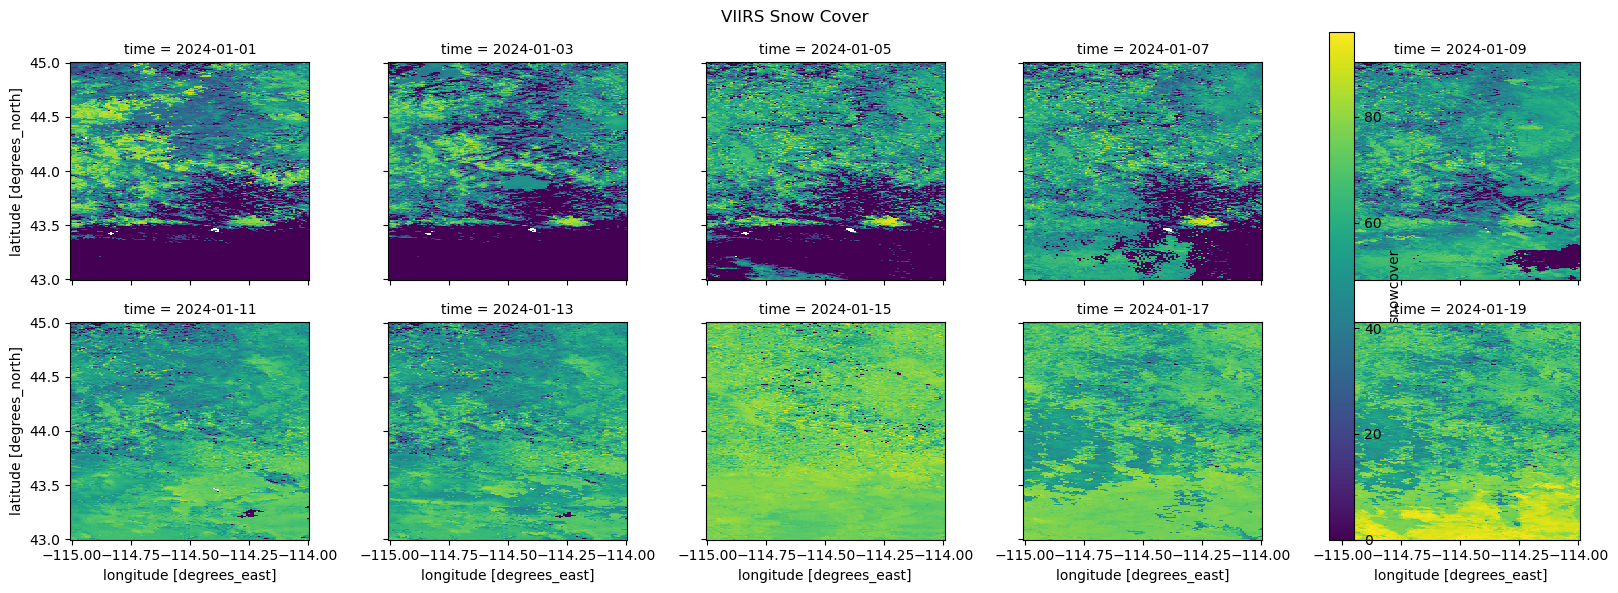

In [16]:
viirs[:20:2].plot(col = 'time', col_wrap = 5)
import matplotlib.pyplot as plt
plt.suptitle('VIIRS Snow Cover')
plt.tight_layout()

In [5]:
ims = download_snow_cover(viirs.time.values, viirs.isel(time = 0), tmp_dir='/Users/zmhoppinen/Documents/spicy-snow/local/ims')

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_10990/1394286589.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


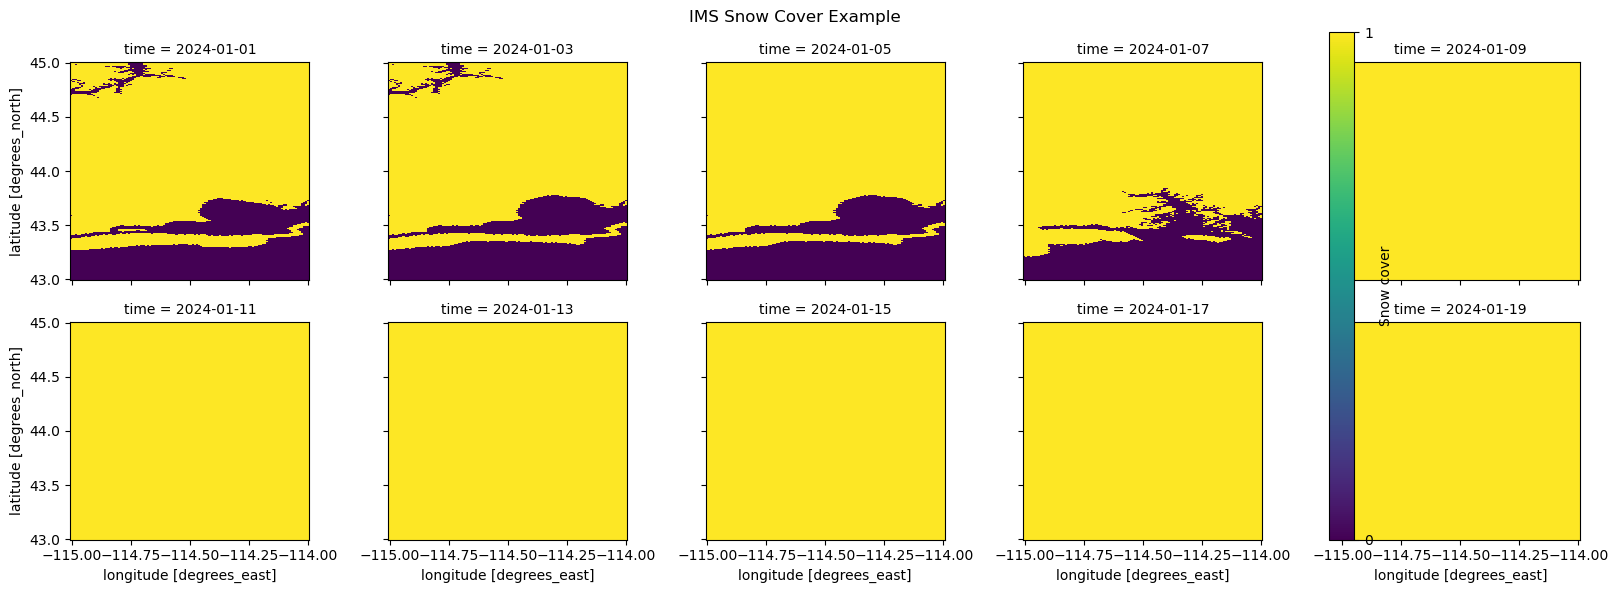

In [20]:
(ims[:20:2] == 4).plot(
    col='time', 
    col_wrap=5,
    cbar_kwargs={
        'ticks': [0, 1],
        'label': 'Snow cover',
    }
)
plt.suptitle('IMS Snow Cover Example')
plt.tight_layout()